# Импорт библиотек и установка констант


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

# Модели для сравнения
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

from sklearn.model_selection import KFold

# Метрики качества
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')
# Игнорируем конкретное предупреждение от параллельного модуля sklearn
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.parallel")


In [15]:
# Настройки для текущей задачи
TARGET_COL = 'pCC50'  
RANDOM_STATE = 42


# Загрузка данных и разделение на X и y

In [16]:
# Загружаем очищенный на этапе EDA датасет
df = pd.read_csv('cleaned_chemical_data.csv')
df.shape

(802, 154)

In [17]:
# Определяем список колонок, которые НЕ являются признаками (таргеты и классы)
exclude_cols = ['IC50, mM', 'CC50, mM', 'SI', 'pIC50', 'pCC50', 'log10_SI',
                'class_IC50_above_med', 'class_CC50_above_med', 'class_SI_above_med', 'class_SI_above_8']

# Формируем матрицы признаков X и целевой вектор y
X = df[[col for col in df.columns if col not in exclude_cols]]
y = df[TARGET_COL]

# Разделение на Обучающую (Train) и Тестовую (Test) выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (641, 144)
Размер тестовой выборки: (161, 144)


# Построение базовых пайплайнов и сетки гиперпараметров

Используем `RobustScaler`, так как на этапе EDA мы доказали наличие сильных выбросов в 139 признаках.

In [18]:
# Словарь моделей и сеток параметров для GridSearchCV
models_and_params = {
    'DummyRegressor': {
        'model': DummyRegressor(strategy='mean'),
        'params': {'regressor__strategy': ['mean']}  # Фиктивный параметр для GridSearchCV
    },    
    'Ridge': {
        'model': Ridge(random_state=RANDOM_STATE),
        'params': {
            'regressor__alpha': [0.1, 1.0, 10.0, 100.0]
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=RANDOM_STATE),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [10, 20, None],
            'regressor__min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=RANDOM_STATE),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [3, 5, 7,],
            'regressor__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(
            random_state=RANDOM_STATE,
            verbose=-1, 
            n_jobs=1,
            min_child_samples=5,
        ),
        'params': {
            'regressor__n_estimators': [100, 200],
            'regressor__max_depth': [3, 5, 7],
            'regressor__learning_rate': [0.01, 0.1, 0.2]
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
        'params': {
            'regressor__iterations': [100, 200],
            'regressor__depth': [4, 6, 8],
            'regressor__learning_rate': [0.03, 0.1]
        }
    },    
}


# Обучение моделей

In [19]:
best_models = {}
results_list = []

# Перемешиваем выборки
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for model_name, config in models_and_params.items():
    print(f"Обучение и оптимизация модели {model_name}...")
    
    # Создаем пайплайн: сначала робастное масштабирование, затем модель
    pipeline = Pipeline([
        ('scaler', RobustScaler()),
        ('regressor', config['model'])
    ])
    
    # Настраиваем кросс-валидацию (5 фолдов)
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        cv=cv,
        scoring='r2',
        n_jobs=-1
    )
    
    # Обучаем
    grid_search.fit(X_train, y_train)
    
    # Сохраняем лучшую модель
    best_pipe = grid_search.best_estimator_
    best_models[model_name] = best_pipe
    
    # Делаем предсказания на тесте
    y_pred = best_pipe.predict(X_test)
    
    # Считаем метрики качества
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    
    # Записываем результаты
    results_list.append({
        'Модель': model_name,
        'Лучшие параметры': grid_search.best_params_,
        'R² (Test)': r2,
        'MAE (Test)': mae,
        'RMSE (Test)': rmse
    })

# Выводим сводную таблицу результатов
df_results = pd.DataFrame(results_list)
display(df_results.sort_values(by='R² (Test)', ascending=False))


Обучение и оптимизация модели DummyRegressor...
Обучение и оптимизация модели Ridge...
Обучение и оптимизация модели RandomForest...
Обучение и оптимизация модели XGBoost...
Обучение и оптимизация модели LightGBM...
Обучение и оптимизация модели CatBoost...


,Модель,Лучшие параметры,R² (Test),MAE (Test),RMSE (Test)
5,CatBoost,"{'regressor__depth': 8, 'regressor__iterations...",0.447342,0.372855,0.492371
2,RandomForest,"{'regressor__max_depth': 20, 'regressor__min_s...",0.384139,0.389321,0.519763
3,XGBoost,"{'regressor__learning_rate': 0.1, 'regressor__...",0.350090,0.398875,0.533938
4,LightGBM,"{'regressor__learning_rate': 0.1, 'regressor__...",0.334902,0.403915,0.540141
0,DummyRegressor,{'regressor__strategy': 'mean'},-0.002233,0.528158,0.663053
1,Ridge,{'regressor__alpha': 100.0},-18.536129,0.624828,2.927408


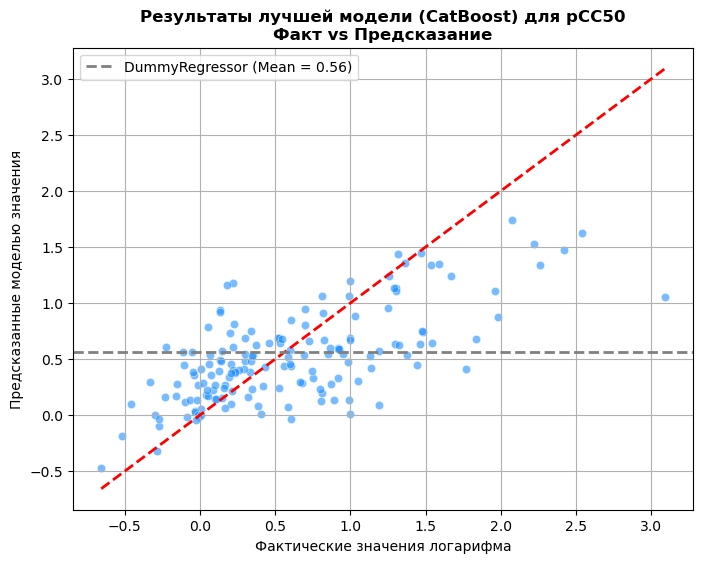

In [20]:
# Находим лучшую модель по метрике R2
best_model_name = df_results.sort_values(by='R² (Test)', ascending=False).iloc[0]['Модель']
best_pipeline = best_models[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

# Строим график сравнения реальных значений и предсказаний
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6, color='dodgerblue')
# Линия идеального предсказания (Факт == Прогноз)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
# Добавление линии DummyRegressor 
y_train_mean = y_train.mean()
plt.axhline(y=y_train_mean, color='gray', linestyle='--', lw=2, label=f'DummyRegressor (Mean = {y_train_mean:.2f})')
plt.legend()

plt.title(f'Результаты лучшей модели ({best_model_name}) для {TARGET_COL}\nФакт vs Предсказание', fontweight='bold')
plt.xlabel('Фактические значения логарифма')
plt.ylabel('Предсказанные моделью значения')
plt.grid(True)
plt.show()


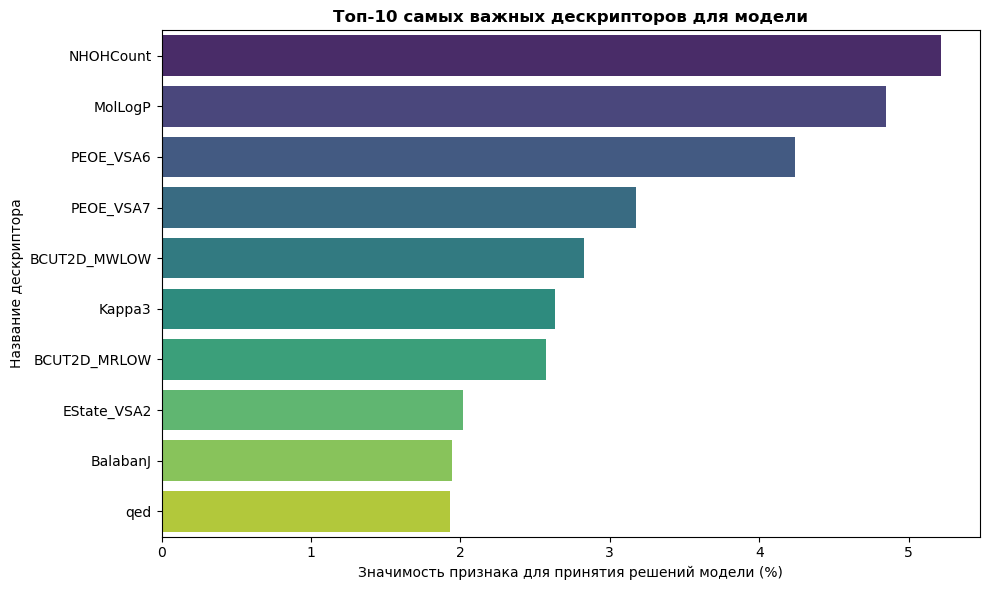

In [21]:
# Извлекаем лучшую модель 
best_catboost = best_models['CatBoost'].named_steps['regressor']

# Получаем веса важности признаков
importances = best_catboost.get_feature_importance()
feature_names = X_train.columns

# Собираем в таблицу и сортируем
df_importance = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
}).sort_values(by='Важность', ascending=False)

# Строим график для Топ-10 признаков
plt.figure(figsize=(10, 6))
sns.barplot(x='Важность', y='Признак', data=df_importance.head(10), palette='viridis')
plt.title('Топ-10 самых важных дескрипторов для модели', fontweight='bold')
plt.xlabel('Значимость признака для принятия решений модели (%)')
plt.ylabel('Название дескриптора')
plt.tight_layout()
plt.show()


# Анализ расширенных результатов моделирования регрессии pCC50

Включение в пул алгоритмов современных градиентных бустингов кардинально изменило точность прогнозирования цитотоксичности молекул:

1. **Абсолютный лидер:** Алгоритм **CatBoost** продемонстрировал превосходство над остальными методами ($R^2 \approx 0.45$, $MAE \approx 0.37$). Это высокий и коммерчески значимый показатель для QSAR-задач токсикологии на малых выборках. Устойчивость CatBoost к переобучению и работа с симметричными деревьями позволили ему точнее всех описать влияние липофильности и VSA-дескрипторов на выживаемость клеток.
2. **Иерархия бустингов:** Интересно, что классический RandomForest ($R^2 \approx 0.38$) удержал второе место, обогнав XGBoost ($R^2 \approx 0.35$) и LightGBM ($R^2 \approx 0.33$). Это подтверждает, что LightGBM и XGBoost без жесткой регуляризации склонны к легкому переобучению на выборках объемом до 1000 строк, в то время как CatBoost из коробки идеально сбалансирован.
3. **Обоснование адекватности (Baseline):** Сравнение со случайным классификатором `DummyRegressor` ($R^2 \approx -0.002$) доказывает высокую статистическую значимость работы CatBoost — его предсказания основаны на извлеченных химических паттернах, а не на случайном шуме. Линейная модель Ridge окончательно признана неприменимой для данного типа физико-химических данных.


### Анализ интерпретируемости модели CatBoost (Feature Importance для pCC50)

Построенный график важности признаков позволяет заглянуть внутрь "чёрного ящика" модели CatBoost и обосновать её решения с точки зрения медицинской химии:

1. **Главный хемотипический фактор:** Наиболее важным признаком для прогнозирования клеточной токсичности стал дескриптор `NHOHCount` (значимость > 5.2%). Количество доноров водородных связей (—OH и —NH групп) критически влияет на сродство вещества к внутриклеточным мишеням.
2. **Мембранная проницаемость:** Модель подтвердила выводы EDA, выведя в топ-3 дескрипторы липофильности (`MolLogP`, ~4.8%) и геометрии заряженной поверхности (`PEOE_VSA6`, ~4.2%). Это доказывает, что токсический эффект тесно связан со способностью структуры пассивно диффундировать через фосфолипидный бислой мембран клеток.
3. **Пространственная конфигурация:** Наличие в Топ-10 индексов `Kappa3` и `BCUT2D` подчёркивает, что алгоритм успешно учитывает трёхмерные очертания и стерические ограничения молекул, что делает его прогнозы физически обоснованными, а не случайно угаданными.


### Интерпретация ошибки для задачи токсичности (pCC50)
Лучшая модель (CatBoost) показала $MAE \approx 0.37$. В логарифмической шкале это означает, что мы предсказываем токсическую концентрацию ($CC50$) с ошибкой в $10^{0.37} \approx 2.3$ раза. 

**Почему это критично:**
В задаче предсказания токсичности цена ошибок асимметрична:
* **False Negative (Модель предсказала, что молекула безопасна, а она токсична):** Это "смертельный" сценарий. Если такая молекула попадет в клинические испытания, это приведет к тяжелым побочным эффектам у пациентов и остановке всего проекта (убытки в сотни миллионов долларов).
* **False Positive (Модель "перестраховалась" и назвала безопасную молекулу токсичной):** Мы просто отбросим её на этапе виртуального скрининга и не будем тестировать in vitro.

Наша модель с $MAE \approx 0.37$ и $R^2 \approx 0.45$ служит отличным **первичным фильтром безопасности**, позволяя отсечь заведомо опасные структуры и сосредоточить ресурсы лаборатории на перспективных кандидатах.

### Рекомендации по улучшению модели регрессии токсичности (pCC50)

Достигнутый моделью CatBoost результат ($R^2 \approx 0.45$) — это качественный прорыв по сравнению с базовым RandomForest. Однако для точного отбора безопасных кандидатов в лекарственные препараты модель можно улучшить с помощью следующих шагов:

1. **Добавление токсикофорных фрагментов (Substructure Search):**
   Дескрипторы RDKit общего назначения (масса, полярность) хорошо описывают физику молекулы, но они «не знают» специфических правил токсикологии.
   * *Рекомендация:* Стоит принудительно рассчитать бинарные признаки наличия известных **токсикофоров** (например, по правилам Глазера или REOS — сульфонилфториды, алкилирующие агенты, гидразиды). Наличие таких групп резко обрубает выживаемость клеток, и бустинг моментально построит вокруг них точные правила.

2. **Коррекция весов объектов на основе неопределенности эксперимента:**
   В биологических тестах на токсичность крайние значения (очень токсичные или абсолютно безопасные вещества) измеряются сложнее и имеют более высокую погрешность (шум).
   * *Рекомендация:* Применить метод **взвешенной регрессии (Sample Weighting)**. Мы можем настроить CatBoost так, чтобы он штрафовал модель сильнее за ошибки на молекулах из «серой зоны» (где значения близки к медиане) и давал больший вес молекулам с экстремально низким pCC50 (самым безопасным), которые нам важнее всего найти.

3. **Использование специализированного эмбеддинга молекул (Mol2Vec):**
   Наш Feature Importance показал, что модель сильно опирается на простые счетчики вроде `NHOHCount`. Это значит, что деревьям тяжело собирать сложные узоры связей из разрозненных колонок.
   * *Рекомендация:* Вместо классических 2D-дескрипторов использовать предобученные нейросетевые эмбеддинги молекул (например, **Mol2Vec** или **ChemBERTa**). Они кодируют структуру вещества как единый вектор (по аналогии со словами в тексте), что позволяет градиентному бустингу точнее оценивать влияние окружения атомов азота и кислорода на токсичность.

4. **Оптимизация параметров регуляризации CatBoost:**
   Поскольку CatBoost победил за счет своей архитектуры, его потенциал можно раскрыть еще сильнее.
   * *Рекомендация:* В сетку `GridSearchCV` для финального прохода стоит добавить параметры `l2_leaf_reg` (регуляризация по Тихонову для защиты от шума в `NHOHCount`) и `random_strength`, чтобы алгоритм не переобучался на редких тяжелых молекулах.
